In [2]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm



0          10
1          10
2          10
3          10
4          10
         ... 
42747    6680
42748    6680
42749    6680
42750    6680
42751    6680
Name: trial, Length: 42752, dtype: int64


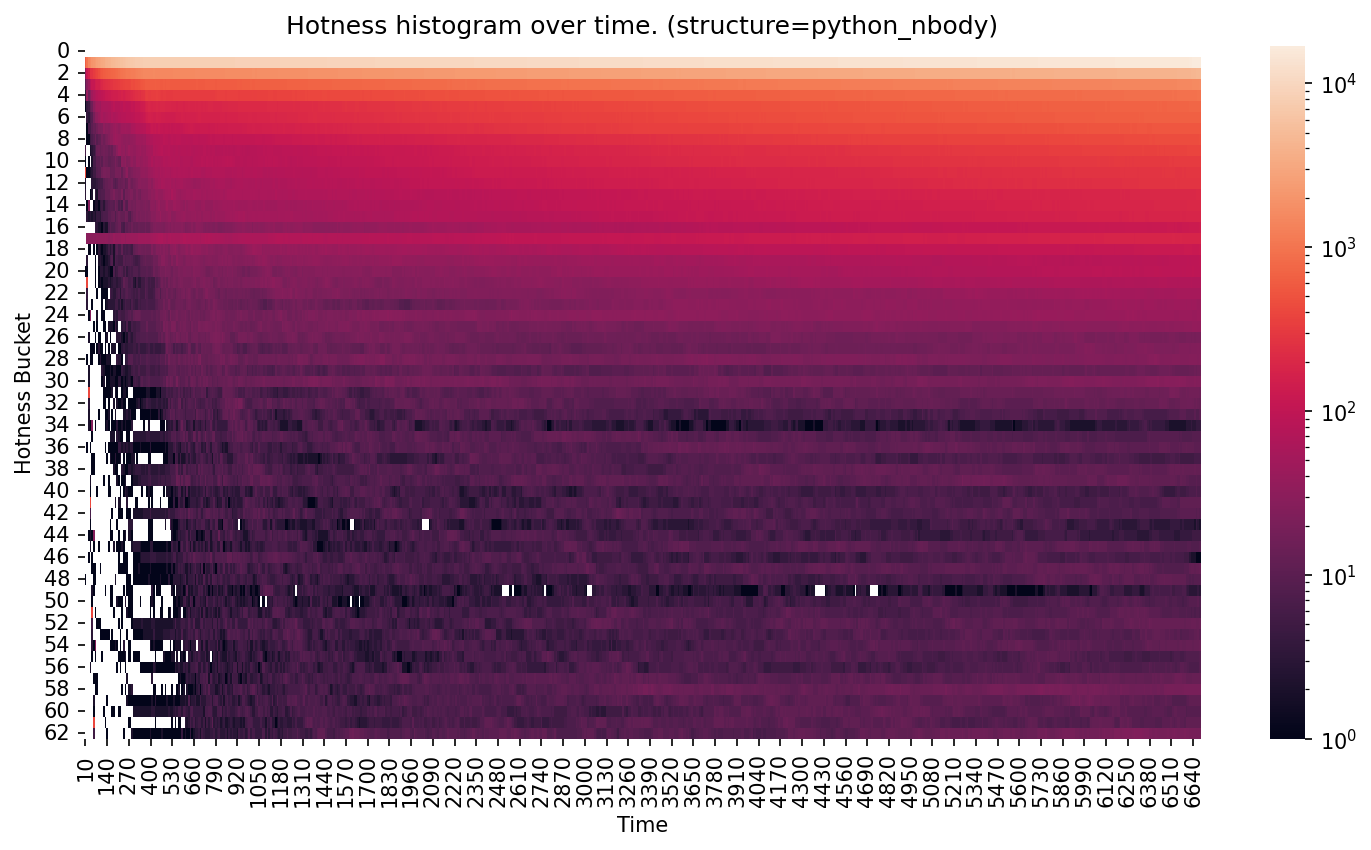

In [19]:
def plot_hist(name):
  df = pd.read_csv(f'../hist_{name}.csv')

  print(df.trial.astype(int))

  # df = df[df.trial < 1000]
  # df = df[df.hotness > 1]
  # df = df[df.hotness > 30]
  df = df[df.hotness < 63]

  # TODO: play with computing rates of change between trials

  # df = df[df['trial'] < 4500]

  # Define custom colormap with specific transitions
  contrasty = LinearSegmentedColormap.from_list(
      "white_gray_black",
      [(0, "white"),
       (0.3, "grey"),
       (1.0, "black")]
  )

  # df['count'] = np.log(df['count'] + 1)
  plt.figure(figsize=(12, 6), dpi=150)
  pivot_table = df.pivot(index="hotness", columns="trial", values="count")
  cmap = contrasty
  # cmap = 'Spectral'
  cmap = None
  sns.heatmap(data=pivot_table,
              norm=LogNorm(),
              cmap=cmap)
  plt.ylabel("Hotness Bucket")
  plt.xlabel("Time")
  plt.title(f"Hotness histogram over time. (structure={name})")

plot_hist('python_nbody')
# plot_hist('pr')
# plot_hist('tc')
# plot_hist('tree')
# plot_hist('table')



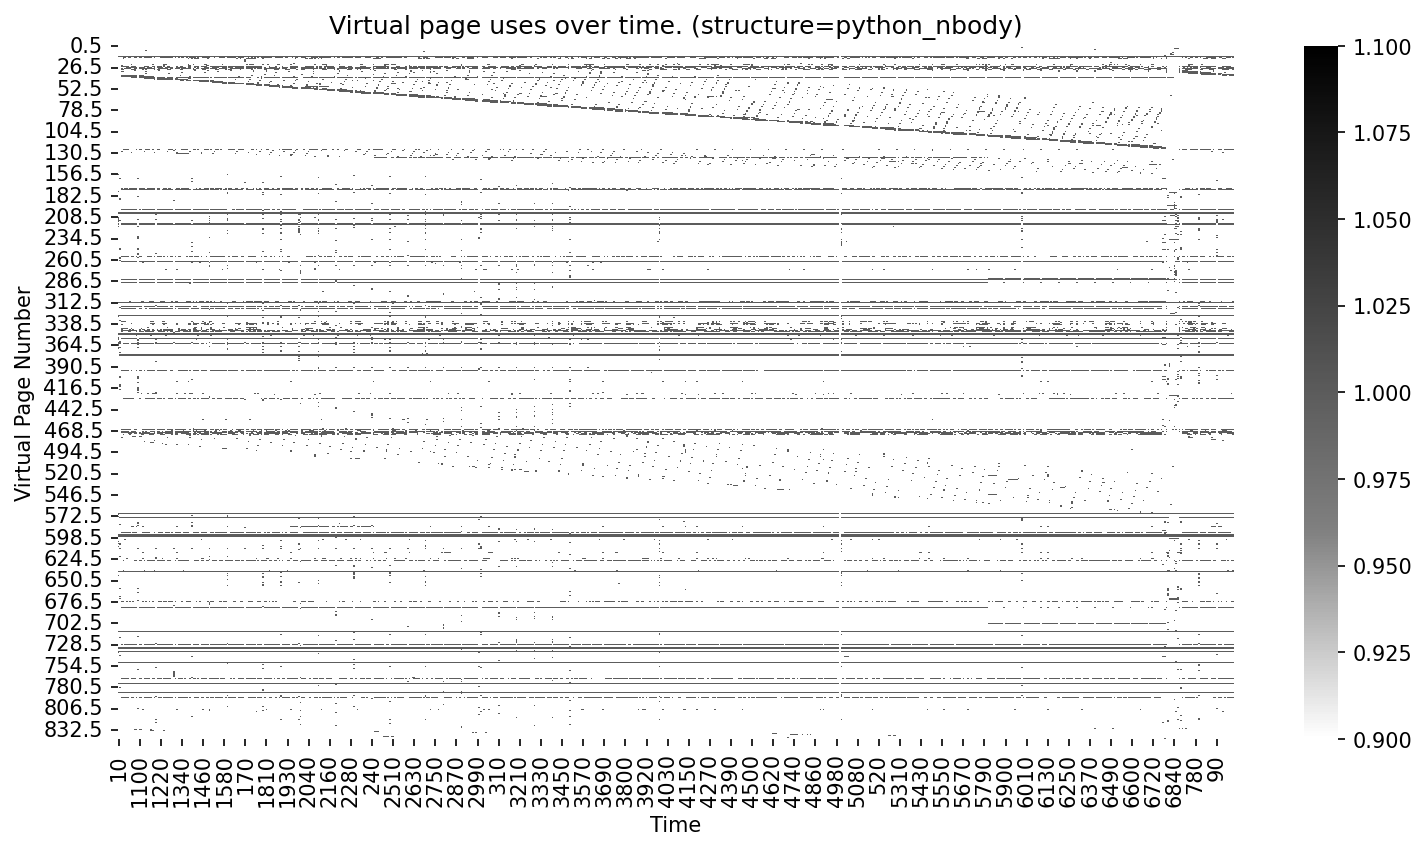

In [23]:
def format_hex(x):
  return x
  return hex(int(x))

def plot_pageuses(name):
  df = pd.read_csv(f'../page_uses_{name}.csv')

  # Define custom colormap with specific transitions
  contrasty = LinearSegmentedColormap.from_list(
      "white_gray_black",
      [(0, "white"),
       (0.3, "grey"),
       (1.0, "black")]
  )
  # df['count'] = np.log(df['count'] + 1)
  plt.figure(figsize=(12, 6), dpi=150)
  pivot_table = df.pivot(index="page", columns="trial", values="accessed")
  cmap = contrasty
  # cmap = 'Spectral'
  # cmap = None
  sns.heatmap(data=pivot_table, cmap=cmap)

  plt.yticks(ticks=plt.yticks()[0], labels=[format_hex(y) for y in plt.yticks()[0]])
  plt.ylabel("Virtual Page Number")
  plt.xlabel("Time")
  plt.title(f"Virtual page uses over time. (structure={name})")

plot_pageuses('python_nbody')